In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sn
import time
import math as m
import scipy.stats

Zadanie 1

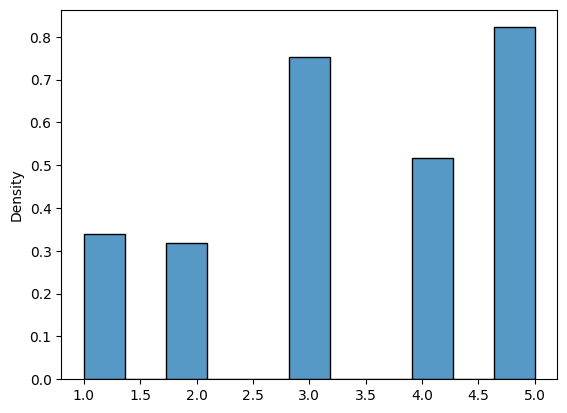

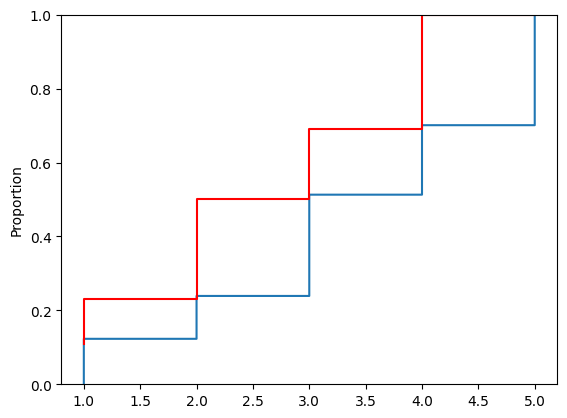

In [6]:
#a

def generate_1a(X, P, n):
    res = []
    for _ in range(n):
        Q = []
        for j in range(len(P)):
            for _ in range(int(P[j]*100)):
                Q.append(X[j])
        I = np.random.randint(0,99)
        res.append(Q[I])
    return res


X = [1,2,3,4,5]
P = [0.11, 0.12, 0.27, 0.19, 0.31]
tab = generate_1a(X, P, 1000)
sn.histplot(tab, stat='density')
plt.show()
theor = np.cumsum(P)
sn.ecdfplot(tab)
plt.step(X, theor, 'r')
plt.show()

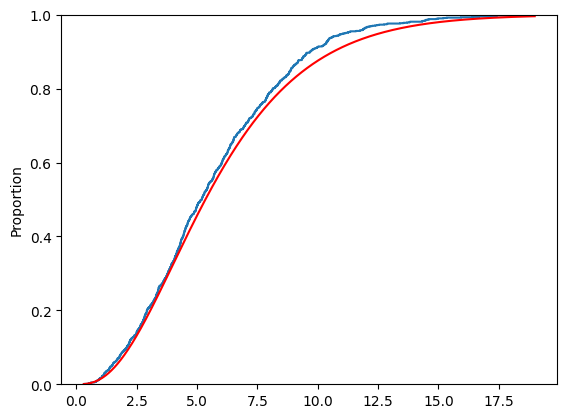

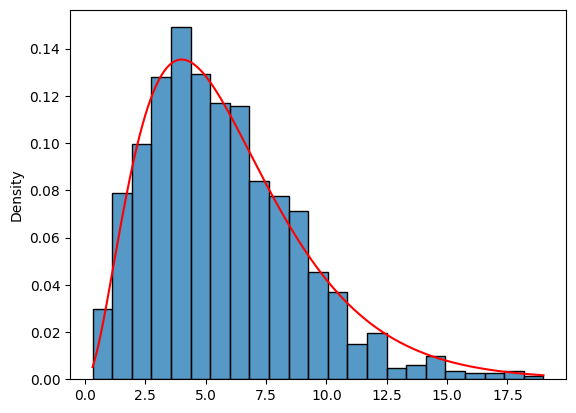

In [2]:
#b
def f(x):
    return x**2 * np.exp(-x/2) / 16

def g(x):
    return np.exp(-x/2) / 2

def generate_1b():
    while True:
        Y = np.random.exponential(2)
        c = 0
        U = random.uniform(0,1)
        for i in np.linspace(0,10,100):
            sup = f(i)/g(i)
            if sup > c:
                c = sup
        if U <= f(Y)/(c*g(Y)):
            return Y
        
tab = [generate_1b() for _ in range(1000)]
x_arg = np.linspace(min(tab), max(tab),1000)
#distributor
gamma = scipy.stats.gamma.cdf(x_arg, a=3, scale=2)
sn.ecdfplot(tab)
plt.plot(x_arg, gamma, 'r')
plt.show()
#density
sn.histplot(tab, stat='density')
plt.plot(x_arg, f(x_arg), 'r')
plt.show()

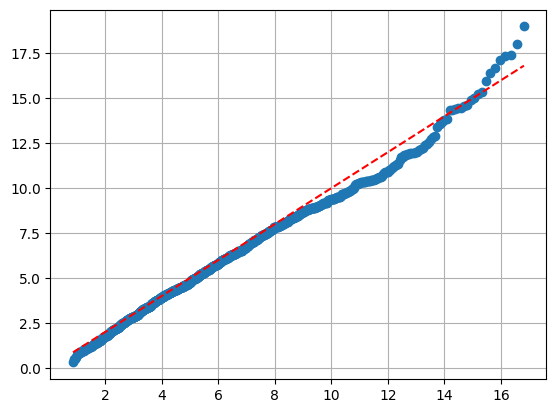

5.669262771304802 6
9.59188716921568 12


In [3]:

tab_sorted = np.sort(tab)
theor_q = scipy.stats.gamma.ppf(np.linspace(0.01, 0.99, len(tab)), a=3, scale=2)

plt.plot(theor_q, tab_sorted, 'o')
plt.plot(theor_q, theor_q, 'r--')
plt.grid(True)
plt.show()

emp_mean = np.mean(tab)
emp_var = np.var(tab)
theor_mean = 3 * 2
theor_var = 3 * 2**2
print(emp_mean, theor_mean)
print(emp_var, theor_var)

Zadanie 2

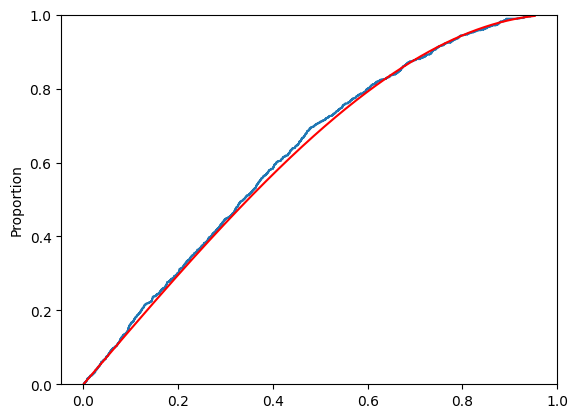

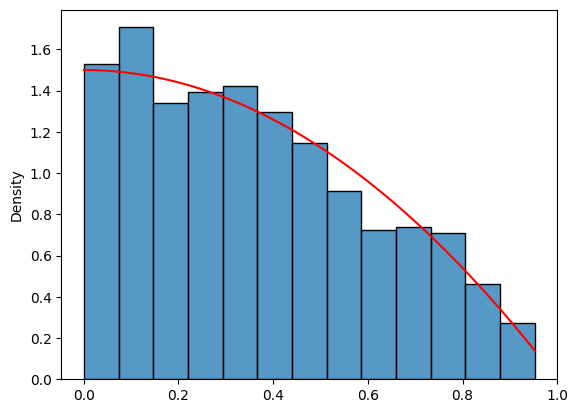

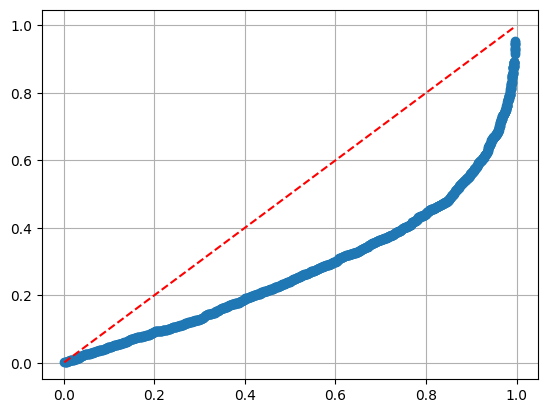

0.3683977728024705 6
0.05975620425657542 12


In [8]:
def f2a(x):
    return (3 / 2) * (1 - x**2)

def generate_2a():
    while True:
        U = np.random.uniform(0,1)
        m = 0
        for k in np.linspace(0, 1, 100):
            if f2a(k) > m:
                m = f2a(k)
        V = np.random.uniform(0,m)
        if V <= f2a(U):
            return U

tab = [generate_2a() for _ in range(1000)]

x_arg = np.linspace(min(tab), max(tab),1000)
#distributor
F = -1/2 * x_arg * (x_arg**2 - 3)
sn.ecdfplot(tab)
plt.plot(x_arg, F, 'r')
plt.show()
#density
sn.histplot(tab, stat='density')
plt.plot(x_arg, f2a(x_arg), 'r')
plt.show()

tab_sorted = np.sort(tab)

plt.plot(F, tab_sorted, 'o')
plt.plot(F, F, 'r--')
plt.grid(True)
plt.show()

emp_mean = np.mean(tab)
emp_var = np.var(tab)

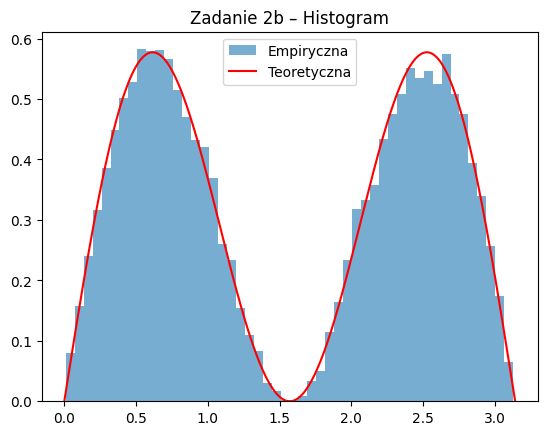

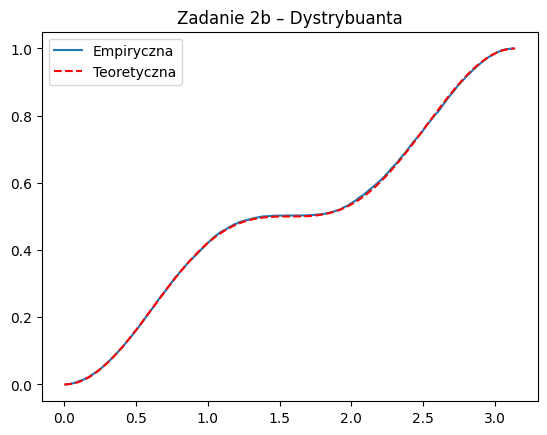

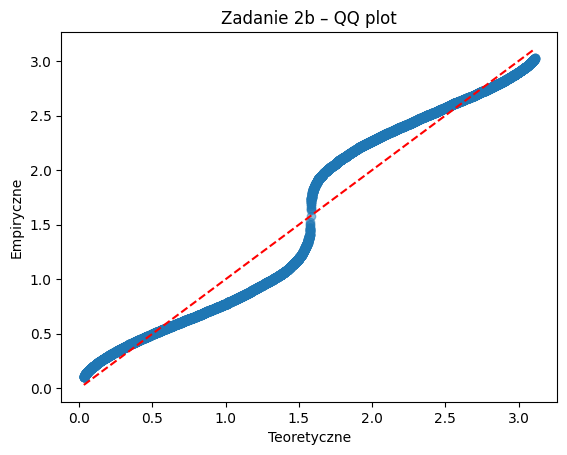

Empiryczna średnia: 1.5678398958910345
Teoretyczna średnia: 1.5707924432426186
Empiryczna wariancja: 0.9128629595472597
Teoretyczna wariancja: 0.9118394444646583


In [9]:
def zad2b(n=10000):
    f = lambda x: 1.5 * np.sin(x) * np.cos(x)**2
    x_vals = np.linspace(0, np.pi, 1000)
    m = max(f(x_vals))

    samples = []
    while len(samples) < n:
        U = np.random.uniform(0, np.pi)
        V = np.random.uniform(0, m)
        if V <= f(U):
            samples.append(U)

    samples = np.array(samples)
    plt.hist(samples, bins=50, density=True, alpha=0.6, label='Empiryczna')
    plt.plot(x_vals, f(x_vals), 'r-', label='Teoretyczna')
    plt.title('Zadanie 2b - Histogram')
    plt.legend()
    plt.show()

    sorted_samples = np.sort(samples)
    empirical_cdf = np.arange(1, n + 1) / n
    theoretical_cdf = np.array([np.trapezoid(f(x_vals[x_vals <= xi]), x_vals[x_vals <= xi]) for xi in x_vals])
    plt.plot(sorted_samples, empirical_cdf, label='Empiryczna')
    plt.plot(x_vals, theoretical_cdf, 'r--', label='Teoretyczna')

    plt.legend()
    plt.show()

    theoretical_quantiles = np.quantile(x_vals, np.linspace(0.01, 0.99, n))
    empirical_quantiles = np.quantile(samples, np.linspace(0.01, 0.99, n))
    plt.scatter(theoretical_quantiles, empirical_quantiles, alpha=0.5)
    plt.plot(theoretical_quantiles, theoretical_quantiles, 'r--')
    plt.xlabel('Teoretyczne')
    plt.ylabel('Empiryczne')
    plt.show()

    print("Empiryczna średnia:", np.mean(samples))
    mean_theoretical = np.trapezoid(x_vals * f(x_vals), x_vals)
    print("Teoretyczna średnia:", mean_theoretical)
    print("Empiryczna wariancja:", np.var(samples))
    var_theoretical = np.trapezoid((x_vals - mean_theoretical)**2 * f(x_vals), x_vals)
    print("Teoretyczna wariancja:", var_theoretical)
    

zad2b()

Współczynnik akceptacji: 0.6103


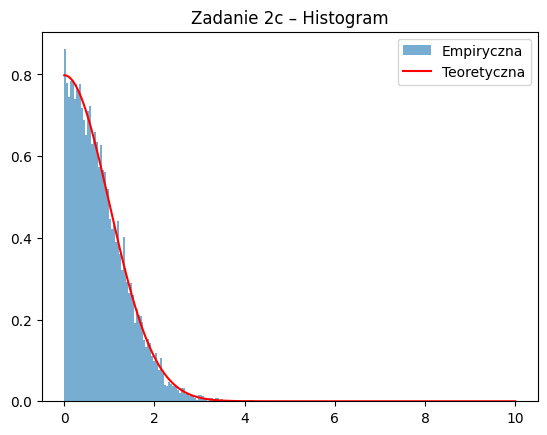

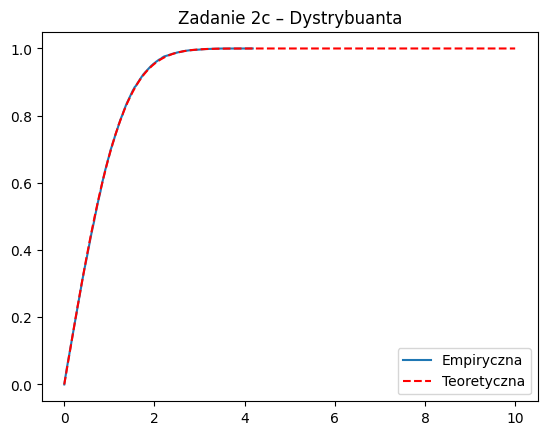

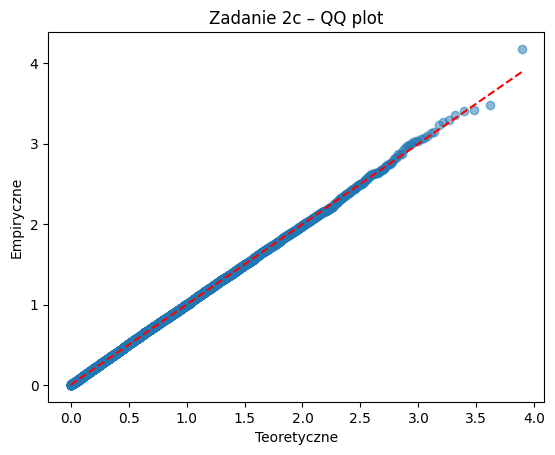

Empiryczna średnia: 0.7975639606510969
Teoretyczna średnia: 0.797884494299182
Empiryczna wariancja: 0.3596842482478136
Teoretyczna wariancja: 0.3633803337569389


In [11]:
def zad2c(n=10000):
    lam = 1.5
    f = lambda x: 2 * scipy.stats.norm.pdf(x)
    g = lambda x: lam * np.exp(-lam * x)
    h = lambda x: f(x) / g(x)
    x_vals = np.linspace(0, 10, 10000)
    c = np.max(h(x_vals))

    samples = []
    attempts = 0
    while len(samples) < n:
        Y = np.random.exponential(1/lam)
        U = np.random.rand()
        if U <= f(Y) / (c * g(Y)):
            samples.append(Y)
        attempts += 1

    samples = np.array(samples)
    acceptance_rate = n / attempts
    print(f"Współczynnik akceptacji: {acceptance_rate:.4f}")

    # Histogram i gęstość
    plt.hist(samples, bins=100, density=True, alpha=0.6, label='Empiryczna')
    plt.plot(x_vals, f(x_vals), 'r-', label='Teoretyczna')
    plt.title('Zadanie 2c – Histogram')
    plt.legend()
    plt.show()

    # Dystrybuanta
    sorted_samples = np.sort(samples)
    empirical_cdf = np.arange(1, n + 1) / n
    theoretical_cdf = scipy.stats.norm.cdf(x_vals) - scipy.stats.norm.cdf(0)
    theoretical_cdf /= theoretical_cdf[-1]
    plt.plot(sorted_samples, empirical_cdf, label='Empiryczna')
    plt.plot(x_vals, theoretical_cdf, 'r--', label='Teoretyczna')
    plt.title('Zadanie 2c – Dystrybuanta')
    plt.legend()
    plt.show()

    # QQ plot
    theoretical_quantiles = scipy.stats.norm.ppf(np.linspace(0.5/n, 1 - 0.5/n, n))
    theoretical_quantiles = theoretical_quantiles[theoretical_quantiles > 0]  # tylko R+
    empirical_quantiles = np.quantile(samples, np.linspace(0, 1, len(theoretical_quantiles)))
    plt.scatter(theoretical_quantiles, empirical_quantiles, alpha=0.5)
    plt.plot(theoretical_quantiles, theoretical_quantiles, 'r--')
    plt.title('Zadanie 2c – QQ plot')
    plt.xlabel('Teoretyczne')
    plt.ylabel('Empiryczne')
    plt.show()

    # Średnia i wariancja
    print("Empiryczna średnia:", np.mean(samples))
    mean_theoretical = np.trapezoid(x_vals * f(x_vals), x_vals)
    print("Teoretyczna średnia:", mean_theoretical)
    print("Empiryczna wariancja:", np.var(samples))
    var_theoretical = np.trapezoid((x_vals - mean_theoretical)**2 * f(x_vals), x_vals)
    print("Teoretyczna wariancja:", var_theoretical)
    

zad2c()

Zadanie 3

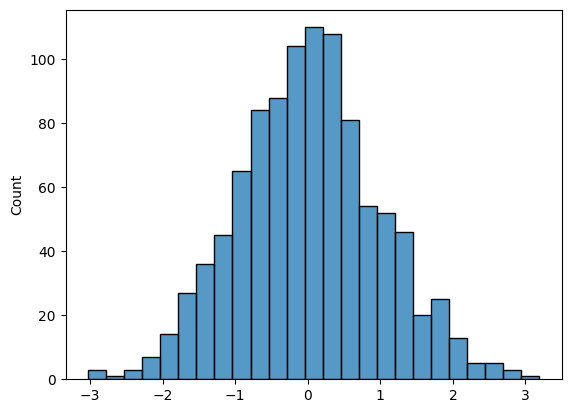

In [ ]:
def Box_Muller_method(n):
    variables = []
    for _ in range(n):
        U1, U2 = np.random.uniform(0,1), np.random.uniform(0,1)
        variables.extend([np.sqrt(-2 * np.log(U1)) * np.cos(2 * np.pi * U2), np.sqrt(-2 * np.log(U1)) * np.sin(2 * np.pi * U2)])
    
    return variables

X = Box_Muller_method(500)
sn.histplot(X)
plt.show()


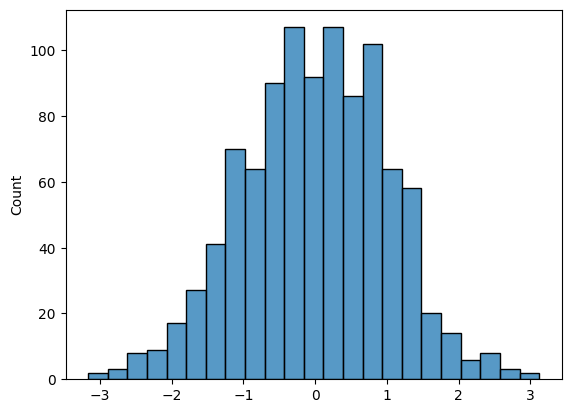

In [7]:
#zadanie 4

def polar_Box_Muller_method(n):
    variables = []
    for _ in range(n):
        while True:
            U1, U2 = random.uniform(-1,1), random.uniform(-1, 1)
            R_squared = U1**2 + U2**2
            if R_squared < 1:
                variables.extend([U1 * np.sqrt(-2 * np.log(R_squared)/R_squared), U2 * np.sqrt(-2 * np.log(R_squared)/R_squared)])
                break
    return variables

sn.histplot(polar_Box_Muller_method(500))
plt.show()


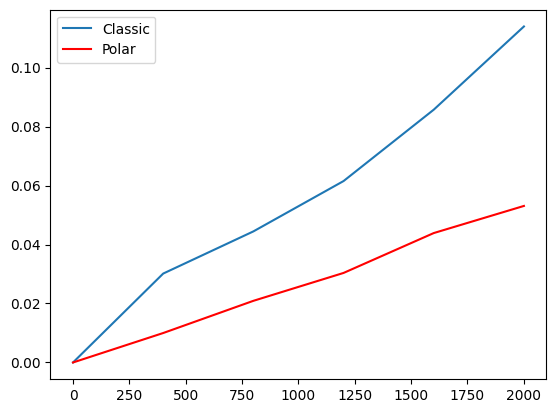

In [8]:
classic, polar = [], []
sample = range(0, 10001, 2000)

for i in sample:
    
    start_c = time.time()
    Box_Muller_method(i)
    end_c = time.time()
    classic.append(end_c - start_c)

    start_p = time.time()
    polar_Box_Muller_method(i)
    end_p = time.time()
    polar.append(end_p - start_p)    

plt.plot(np.linspace(0, 2001, 6), classic, label='Classic')
plt.plot(np.linspace(0, 2001, 6), polar, label='Polar', c='r')
plt.legend()
plt.show()